# Crates.io Dependency Network Community Detection

## 社区结构与功能模块

利用社区发现算法（如 Louvain 或 Leiden）来对网络进行无监督分区。

*   **发现领域集群**：看看社区是否自然形成了“前端渲染”、“网络请求”、“命令行工具”、“游戏开发”、“嵌入式”等板块。
*   **交叉验证**：可以爬取crate的分类信息（如 `categories` 字段），看社区发现的划分与人工标签是否一致。不一致的地方往往隐藏着有趣的多面手crate或误分类情况。
*   **桥梁分析**：找出连接不同社区的**边界节点**，它们往往是最具创新性的crate，但也是风险交叉传染的通道。


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import json

from utils import largest_component_graph, write_json

from enum import Enum
class Snapshot(Enum):
    SNAPSHOT_2018_09_26 = "2018-09-26"
    SNAPSHOT_2020_11_20 = "2020-11-20"
    SNAPSHOT_2022_07_06 = "2022-07-06"
    SNAPSHOT_2024_03_11 = "2024-03-11"
    SNAPSHOT_2026_05_25 = "2026-05-25"

## Configuration

In [2]:
from dataclasses import dataclass
date = Snapshot.SNAPSHOT_2018_09_26.value
root_dir = Path(f"outputs_{date}")
@dataclass
class AnalysisConfig:
    edges: Path
    nodes: Path
    out_dir: Path = root_dir / "analysis"
    path_samples: int = 50
    top_k: int = 30
    seed: int = 7
    skip_powerlaw: bool = False
    skip_community: bool = False
    skip_pagerank: bool = False

args = AnalysisConfig(
    edges=root_dir / "core_edges.csv",
    nodes=root_dir / "core_nodes.csv",
    out_dir=root_dir / "analysis",
    top_k=60,
)

out_dir = args.out_dir
out_dir.mkdir(parents=True, exist_ok=True)

In [3]:
graph = nx.DiGraph()
graph = nx.read_gml(out_dir.parent / "core_graph.gml")
undirected = graph.to_undirected()
undirected = largest_component_graph(undirected)

In [4]:
print("Community detection")
communities: list[set[str]] = list(
    nx.algorithms.community.louvain_communities(undirected, seed=args.seed)
)

print(len(communities), communities[0])

Community detection
22 {'ncollide_transformation', 'rsgenetic', 'vulkano-shaders', 'nuklear-sys', 'oxcable-basic-devices', 'specs_bundler', 'game2048', 'hamcrest', 'simulacrum', 'resize', 'pdf', 'iter-read', 'apath', 'stream-dct', 'glowygraph', 'stl_io', 'ncollide_queries', 'elias-fano', 'daggy', 'rusty_gl', 'boolean_expression', 'mold2d', 'rustiff', 'lafont', 'lfa', 'mikktspace', 'wana_kana', 'sdl2_mixer', 'any_key', 'rms', 'diwata_server', 'spade', 'airspy', 'o2lsh', 'chinese-numbers', 'hematite', 'elmesque', 'fin', 'cuivre', 'corange-rs', 'piston2d-opengl_graphics', 'cppn', 'rshyeong', 'aflak_imgui-glium-renderer', 'fixedbitset', 'ezomyte', 'imgref', 'piston-gfx_texture', 'ncollide_testbed3d', 'carboxyl', 'picto', 'ambisonic', 'simple_asn1', 'rosalind', 'glhelper', 'mat4', 'piston3d-construct', 'lib_xch', 'screenruster-saver-laughing_man', 'coreaudio-sys', 'weighted-regexp', 'pdf-canvas', 'ripsolve', 'lazy_transducer', 'ezing', 'collada', 'find_folder', 'noptim', 'polylabel_cmd', 'r

In [5]:
sorted_communities = sorted(communities, key=len, reverse=True)
print(len(sorted_communities[0]), sorted_communities[0])
sizes = sorted((len(comm) for comm in communities), reverse=True)
modularity = None
if communities:
    modularity = float(nx.algorithms.community.quality.modularity(undirected, communities))

summary = {
    "algorithm": "louvain_communities",
    "communities": len(communities),
    "top_sizes": sizes[:20],
    "modularity": modularity,
}
write_json(out_dir / "community_summary.json", summary)


1766 {'ghopac', 'ruplace', 'racer-interner', 'google-kgsearch1', 'google-dfareporting2d3-cli', 'google-qpxexpress1', 'rgs_models', 'google-autoscaler1_beta2-cli', 'rincon_client', 'dao', 'cbindgen', 'google-container1-cli', 'rist', 'alphred', 'sdoc', 'iron-test', 'juniper_rocket', 'rusoto_support', 'alfred-rs', 'google-clouderrorreporting1_beta1', 'pebble', 'rusoto_serverlessrepo', 'safety', 'google-content2', 'untis', 'cpp_codegen', 'handlebars', 'configurator', 'google-servicecontrol1', 'google-cloudkms1-cli', 'caniuse', 'serde-helpers', 'bodyparser', 'rosrust', 'vent', 'serde_rustc_serialize_interop', 'unixbar', 'google-admin1_directory', 'google-videointelligence1_beta1', 'urbandict', 'google-oslogin1', 'git-changelog', 'google-cloudtrace1', 'duniter-wotb', 'doc-comment', 'google-appsactivity1-cli', 'google-runtimeconfig1_beta1-cli', 'google-slides1', 'activitystreams-traits', 'currency_layer', 'dpdk-serde', 'rusoto_marketplace_entitlement', 'serde_mcf', 'buerostatus', 'rusoto_reso

In [ ]:
# For Windows users, you can use the following PowerShell command to download the file:
!Start-BitsTransfer -Source "https://static.crates.io/db-dump.tar.gz" -Destination "f:\db-dump.tar.gz"
!tar -xzvf "f:\db-dump.tar.gz" -C "f:\db-dump"

# For Linux/Mac users, you can use the following command in the terminal:
# !wget -O db-dump.tar.gz https://static.crates.io/db-dump.tar.gz
# !tar -xzvf db-dump.tar.gz -C db-dump

In [18]:
db_dump_dir = Path(r"f:\db-dump\2026-05-26-020032")
labels_path = out_dir / "crate_labels.csv"
!cargo run -q --release --bin extract_labels -- --db-dir "{db_dump_dir}" --out "{labels_path}"

Output: outputs_2018-09-26\community\crate_labels.csv
Crates: 273391
Crates with categories: 118671
Crates with keywords: 150936


In [13]:
from collections import defaultdict
from tqdm.auto import tqdm

community_map = {}
for idx, comm in enumerate(communities):
    for node in comm:
        community_map[node] = idx

cross_counts: dict[str, int] = defaultdict(int)
neighbor_comm_counts: dict[str, dict[int, int]] = defaultdict(lambda: defaultdict(int))

for u, v in tqdm(undirected.edges(), desc="Counting community edges", unit="edges"):
    cu = community_map.get(u)
    cv = community_map.get(v)
    if cu is None or cv is None:
        continue
    neighbor_comm_counts[u][cv] += 1
    neighbor_comm_counts[v][cu] += 1
    if cu != cv:
        cross_counts[u] += 1
        cross_counts[v] += 1

participation: dict[str, float] = {}
for node, counts in neighbor_comm_counts.items():
    k = sum(counts.values())
    if k == 0:
        participation[node] = 0.0
    else:
        participation[node] = 1.0 - sum((c / k) ** 2 for c in counts.values())

min_degree = 10
top_cross = sorted(cross_counts.items(), key=lambda x: x[1], reverse=True)[:20]
top_part = sorted(
    ((n, p) for n, p in participation.items() if undirected.degree(n) >= min_degree),
    key=lambda x: x[1],
    reverse=True,
 )[:20]

print("Top cross-community nodes:")
for rank, (name, count) in enumerate(top_cross, start=1):
    deg = undirected.degree(name)
    part = participation.get(name, 0.0)
    print(rank, name, count, f"deg={deg}", f"P={part:.3f}")

print(f"Top participation coefficient (degree >= {min_degree}):")
for rank, (name, score) in enumerate(top_part, start=1):
    deg = undirected.degree(name)
    cross = cross_counts.get(name, 0)
    print(rank, name, f"P={score:.3f}", f"deg={deg}", f"cross={cross}")

Counting community edges: 100%|██████████| 53580/53580 [00:00<00:00, 882969.74edges/s]

Top cross-community nodes:
1 log 1119 deg=1772 P=0.819
2 serde 938 deg=2451 P=0.601
3 clap 874 deg=1301 P=0.811
4 lazy_static 778 deg=1121 P=0.858
5 libc 777 deg=1927 P=0.624
6 rand 736 deg=1150 P=0.808
7 serde_derive 679 deg=1959 P=0.557
8 chrono 601 deg=738 P=0.853
9 regex 553 deg=957 P=0.780
10 byteorder 549 deg=914 P=0.792
11 serde_json 549 deg=1837 P=0.494
12 failure 510 deg=741 P=0.833
13 error-chain 509 deg=653 P=0.849
14 time 361 deg=564 P=0.819
15 rustc-serialize 357 deg=550 P=0.819
16 toml 342 deg=433 P=0.849
17 hyper 323 deg=989 P=0.509
18 futures 305 deg=883 P=0.530
19 url 289 deg=702 P=0.619
20 itertools 252 deg=331 P=0.871
Top participation coefficient (degree >= 10):
1 electrs P=0.877 deg=25 cross=23
2 pf_sandbox_lib P=0.875 deg=24 cross=21
3 livesplit-core P=0.872 deg=17 cross=14
4 itertools P=0.871 deg=331 cross=252
5 bitcask-rs P=0.867 deg=14 cross=13
6 dfw P=0.867 deg=16 cross=13
7 indexmap P=0.862 deg=31 cross=23
8 linked-hash-map P=0.861 deg=49 cross=37
9 json-job-

In [ ]:
def load_json(path: Path):
    if not path.exists():
        print(f"Missing: {path}")
        return None
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)
community_summary = load_json(out_dir / "community_summary.json")


Community summary:
{
  "algorithm": "louvain_communities",
  "communities": 22,
  "top_sizes": [
    1766,
    1730,
    1696,
    1522,
    1450,
    1364,
    670,
    591,
    562,
    513,
    485,
    394,
    391,
    358,
    156,
    143,
    55,
    38,
    27,
    6
  ],
  "modularity": 0.5039967383494117
}


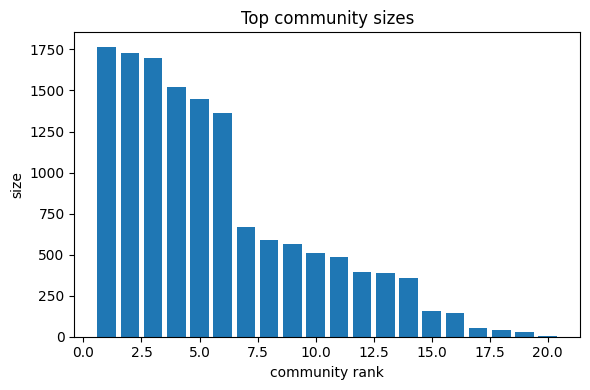

In [15]:
if community_summary:
    if community_summary.get("skipped"):
        print("Community detection skipped:", community_summary.get("reason"))
    else:
        print("Community summary:")
        print(json.dumps(community_summary, indent=2))
        sizes = community_summary.get("top_sizes", [])
        if sizes:
            plt.figure(figsize=(6, 4))
            plt.bar(range(1, len(sizes) + 1), sizes)
            plt.title("Top community sizes")
            plt.xlabel("community rank")
            plt.ylabel("size")
            plt.tight_layout()
            plt.show()

In [19]:
import csv
from collections import Counter



if not labels_path.exists():
    print("Generate labels with Rust:")
    print(f"cargo run --release --bin extract_labels -- --db-dir \"{db_dump_dir}\" --out \"{labels_path}\"")
else:
    def load_labels(path: Path) -> dict[str, dict[str, list[str]]]:
        labels = {}
        with path.open(newline="", encoding="utf-8") as handle:
            reader = csv.DictReader(handle)
            for row in reader:
                name = row.get("crate")
                if not name:
                    continue
                categories = [c for c in row.get("categories", "").split(";") if c]
                keywords = [k for k in row.get("keywords", "").split(";") if k]
                labels[name] = {"categories": categories, "keywords": keywords}
        return labels

    labels = load_labels(labels_path)

    def summarize_labels(
            comm: set[str], 
            labels: dict[str, dict[str, list[str]]], 
            key: str, 
            top_k: int = 5
        ) -> tuple[int, float, list[tuple[str, int]]]:
        counts = Counter()
        labeled_nodes = 0
        for node in comm:
            items = labels.get(node, {}).get(key, [])
            if items:
                labeled_nodes += 1
                counts.update(set(items))
        top: list[tuple[str, int]] = counts.most_common(top_k)
        purity = (top[0][1] / labeled_nodes) if labeled_nodes and top else 0.0
        return labeled_nodes, purity, top

    top_comm = sorted(communities, key=len, reverse=True)[:10]
    total_labeled = 0
    weighted_purity = 0.0

    print("Top community label summaries (categories):")
    for idx, comm in enumerate(top_comm, start=1):
        labeled, purity, top = summarize_labels(comm, labels, "categories")
        size = len(comm)
        if labeled:
            weighted_purity += purity * labeled
            total_labeled += labeled
        top_str = ", ".join([f"{name}({count})" for name, count in top])
        print(f"#{idx} size={size} labeled={labeled} purity={purity:.3f} top={top_str}")

    if total_labeled:
        print(f"Weighted purity (categories): {weighted_purity / total_labeled:.3f}")

    print("Top community label summaries (keywords):")
    for idx, comm in enumerate(top_comm, start=1):
        labeled, purity, top = summarize_labels(comm, labels, "keywords")
        size = len(comm)
        top_str = ", ".join([f"{name}({count})" for name, count in top])
        print(f"#{idx} size={size} labeled={labeled} purity={purity:.3f} top={top_str}")

Top community label summaries (categories):
#1 size=1766 labeled=398 purity=0.264 top=API bindings(105), Command line utilities(53), Web programming(53), Development tools(39), Encoding(39)
#2 size=1730 labeled=538 purity=0.305 top=Command line utilities(164), Development tools(84), Text processing(61), Command-line interface(54), Filesystem(37)
#3 size=1696 labeled=520 purity=0.296 top=External FFI bindings(154), API bindings(143), GUI(55), Network programming(55), Hardware support(51)
#4 size=1522 labeled=550 purity=0.273 top=Network programming(150), Asynchronous(140), API bindings(62), Command line utilities(51), Web programming(40)
#5 size=1450 labeled=434 purity=0.207 top=Science(90), Algorithms(72), Data structures(54), Game engines(37), Multimedia::Images(36)
#6 size=1364 labeled=463 purity=0.285 top=No standard library(132), Cryptography(131), Data structures(63), Algorithms(60), Encoding(38)
#7 size=670 labeled=199 purity=0.196 top=No standard library(39), Rust patterns(30), 

In [20]:
import wordcloud

out_dir = root_dir / "community"
out_dir.mkdir(parents=True, exist_ok=True)

def get_label_text(
        comm: set[str],
        labels: dict[str, dict[str, list[str]]],
        key: str
    ) -> Counter:
    text_counts = Counter()
    for node in comm:
        items = labels.get(node, {}).get(key, [])
        if items:
            text_counts.update(items)
    return text_counts

for idx, comm in enumerate(top_comm, start=1):
    wc = wordcloud.WordCloud(width=1000, height=600, background_color="white")
    wc.generate_from_frequencies(get_label_text(comm, labels, "categories"))
    wc.to_file(f"{out_dir}/{idx}-categories.png")

for idx, comm in enumerate(top_comm, start=1):
    wc = wordcloud.WordCloud(width=1000, height=600, background_color="white")
    wc.generate_from_frequencies(get_label_text(comm, labels, "keywords"))
    wc.to_file(f"{out_dir}/{idx}-keywords.png")

## Gephi 可视化导出

采用**分层度排序抽样**（stratified degree-based sampling）来高效生成 Gephi 可视化图：
1. 每个社区按其规模分配节点配额，总目标 ~15K 节点（Gephi 交互流畅的阈值）。
2. 社区内部按度数降序选取高影响力节点，保留网络骨架结构。
3. 提取诱导子图并保留最大连通分量。
4. 导出为 **GEXF** 格式（Gephi 原生格式，属性保留最佳），节点附带 `community` 和 `degree` 属性。

在 Gephi 中打开后：
- **布局** → ForceAtlas2（勾选 "Prevent Overlap"）
- **外观** → 节点颜色 → Partition → 选择 `community` 属性
- **外观** → 节点大小 → Ranking → 选择 `degree` 属性


In [15]:
import random
from collections import Counter, defaultdict

random.seed(args.seed)

# ── 1. Build community map ──────────────────────────────────
community_map: dict[str, int] = {}
community_members: dict[int, list[str]] = defaultdict(list)
for idx, comm in enumerate(communities):
    for node in comm:
        community_map[node] = idx
        community_members[idx].append(node)

# ── 2. Stratified degree-based sampling ─────────────────────
TARGET_NODES = 15_000
total_nodes = len(undirected)
sample_nodes: set[str] = set()

for comm_id, members in community_members.items():
    quota = max(3, int(TARGET_NODES * len(members) / total_nodes))
    quota = min(quota, len(members))
    # Sort by degree desc, pick top
    top_members = sorted(members, key=lambda n: undirected.degree(n), reverse=True)[:quota]
    sample_nodes.update(top_members)

print(f"Sampled {len(sample_nodes)} nodes from {len(communities)} communities")

# ── 3. Extract subgraph, keep largest component ──────────────
subgraph = undirected.subgraph(sample_nodes)
subgraph = largest_component_graph(subgraph)
print(f"Induced subgraph: {subgraph.number_of_nodes():,} nodes, {subgraph.number_of_edges():,} edges")

# ── 4. Annotate node attributes for Gephi ────────────────────
for node in subgraph.nodes():
    subgraph.nodes[node]['community'] = community_map.get(node, -1)
    subgraph.nodes[node]['degree'] = subgraph.degree(node)

# ── 5. Export GEXF ───────────────────────────────────────────
gexf_dir = root_dir / "community"
gexf_dir.mkdir(parents=True, exist_ok=True)
gexf_path = gexf_dir / "gephi_community.gexf"
nx.write_gexf(subgraph, str(gexf_path))
print(f"Exported → {gexf_path}")

# ── 6. Quick community stats of sample ───────────────────────
comm_counts = Counter(subgraph.nodes[n]['community'] for n in subgraph.nodes())
print(f"Communities in sample: {len(comm_counts)}, modularity: "
      f"{nx.algorithms.community.quality.modularity(subgraph, [set(c) for c in nx.algorithms.community.louvain_communities(subgraph, seed=args.seed)]):.4f}")

Sampled 15236 nodes from 148 communities
Induced subgraph: 15,135 nodes, 247,406 edges
Exported → outputs_2026-05-25\community\gephi_community.gexf
Communities in sample: 124, modularity: 0.3359
